In [2]:
import torch
from torchvision.io import decode_image
import numpy as np

import matplotlib.pyplot as plt


In [3]:
import torch

def radial_power_spectrum(image):
    # 1. Ensure input is 4D: (Batch, Channels, Height, Width)
    if image.dim() == 3:
        image = image.unsqueeze(0)
    
    B, C, H, W = image.shape
    
    # 2. Compute 2D FFT and shift center
    # Note: Only apply fft and shift over the spatial dimensions (-2, -1)
    f_coeffs = torch.fft.fft2(image, dim=(-2, -1))
    f_shifted = torch.fft.fftshift(f_coeffs, dim=(-2, -1))
    
    # 3. Calculate Power Spectrum: |F(u,v)|^2
    power_2d = torch.abs(f_shifted)**2
    
    # Average the power across channels (standard practice for image/latent PSD)
    # New shape: (B, H, W)
    power_2d = power_2d.mean(dim=1) 
    
    # 4. Create radial coordinate grid
    yc, xc = H // 2, W // 2
    y, x = torch.meshgrid(torch.arange(H) - yc, torch.arange(W) - xc, indexing='ij')
    r = torch.sqrt(x**2 + y**2).to(image.device)
    
    # 5. Binning setup
    r_int = r.round().long()
    max_r = int(min(H, W) / 2)
    
    # Mask out corners of the square image where radius > max_r
    valid_mask = r_int <= max_r
    
    # 6. Accumulate power per radius, per batch
    psd_1d = torch.zeros(B, max_r + 1, device=image.device)
    counts = torch.zeros(max_r + 1, device=image.device)
    
    # Flatten spatial dims to use scatter_add
    # power_flat: (B, H*W) | r_flat: (H*W)
    power_flat = power_2d.view(B, -1)
    r_flat = r_int.flatten()
    
    # We only want to scatter valid radii (ignore corners)
    r_valid = r_flat[valid_mask.flatten()]
    power_valid = power_flat[:, valid_mask.flatten()]
    
    # Scatter add along the spatial dimension (dim=1)
    # r_valid needs to be expanded to match batch size for scatter_add
    r_expanded = r_valid.unsqueeze(0).expand(B, -1)
    psd_1d.scatter_add_(1, r_expanded, power_valid)
    
    # Count the number of pixels at each radius (only need to do this once, not per batch)
    counts.scatter_add_(0, r_valid, torch.ones_like(r_valid, dtype=torch.float32))
    
    # 7. Normalize by counts to get the expectation (mean)
    # Add a tiny epsilon to prevent division by zero for empty bins
    psd_1d = psd_1d / (counts.unsqueeze(0) + 1e-8)
    
    return psd_1d

def plot_psd_1d(psd_1d, sample_idx=0):
    # psd_1d shape is (Batch, Max_R)
    psd_to_plot = psd_1d[sample_idx].cpu().numpy()
    
    # Create frequency axis (0 to 0.5 cycles/pixel is standard)
    freqs = np.arange(len(psd_to_plot))
    
    plt.figure(figsize=(8, 5))
    plt.loglog(freqs, psd_to_plot, label=f"Sample {sample_idx}")
    
    plt.title("Radially Averaged Power Spectral Density")
    plt.xlabel("Frequency (Radius in pixels)")
    plt.ylabel("Power (Log Scale)")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    
    plt.show()
    
def plot_multiple_psd_1d(psd_dict, sample_idx=0):
    plt.figure(figsize=(10, 6))
    
    for label, psd_1d in psd_dict.items():
        psd_to_plot = psd_1d[sample_idx].cpu().numpy()
        
        # Start at 1 to avoid log(0) for the DC component (mean of the image)
        freqs = np.arange(1, len(psd_to_plot))
        psd_to_plot = psd_to_plot[1:] 
        
        plt.loglog(freqs, psd_to_plot, label=label, linewidth=2)
    
    plt.title("Radially Averaged Power Spectral Density (Log-Log)", fontsize=14)
    plt.xlabel("Frequency (Radius in pixels)", fontsize=12)
    plt.ylabel("Power", fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(fontsize=12)
    
    plt.show()

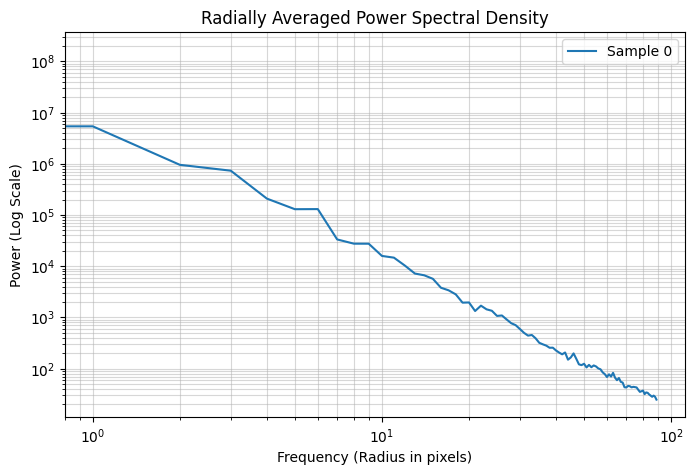

In [4]:
image_path = "./images/000010.jpg"
img_tensor = decode_image(image_path)
img_tensor = img_tensor.float() / 255.0

rps = radial_power_spectrum(img_tensor)
plot_psd_1d(rps)

#### For natural images, PSD follows a staight line, power law distribution

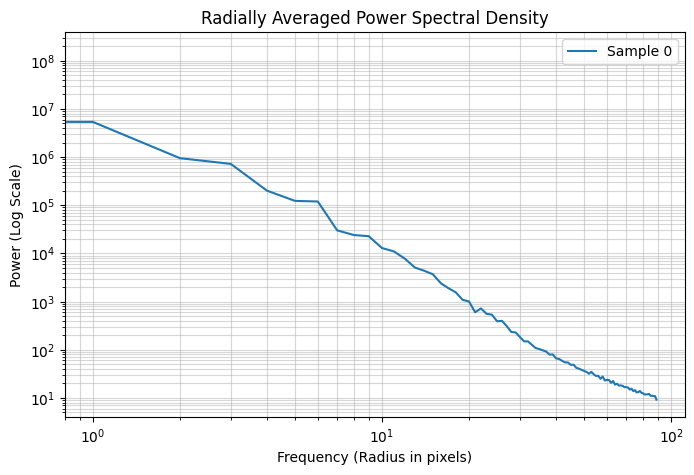

In [5]:
image_path = "./images/000010_blurred.jpg"
img_tensor = decode_image(image_path)
img_tensor = img_tensor.float() / 255.0

rps = radial_power_spectrum(img_tensor)
plot_psd_1d(rps)

#### Blurring the image reduces high frequency components, so the PSD drops off more steeply at higher frequencies.

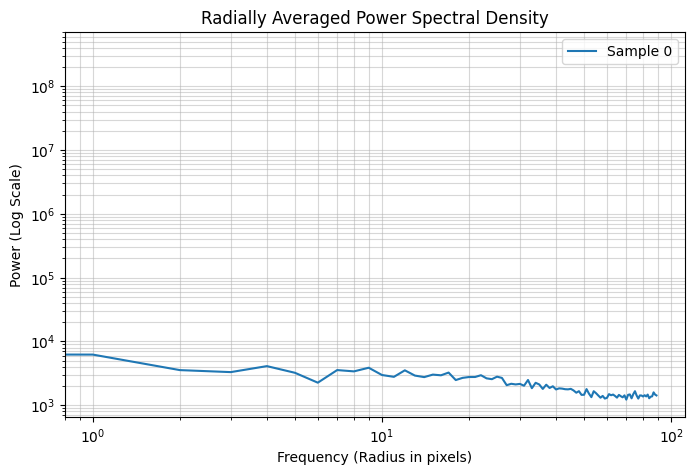

In [6]:
image_path = "./images/random_image.jpg"
img_tensor = decode_image(image_path)
img_tensor = img_tensor.float() / 255.0

rps = radial_power_spectrum(img_tensor)
plot_psd_1d(rps)

#### For a random image, the PSD is relatively flat across frequencies, indicating no dominant spatial structure or correlation.

## PSD of VAE

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from diffusers import AutoencoderKL
from torch.nn import functional as F

/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps
Loading VAE...


/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Encoding Image...
Image shape: torch.Size([1, 3, 512, 512])
Latent shape: torch.Size([1, 4, 64, 64])


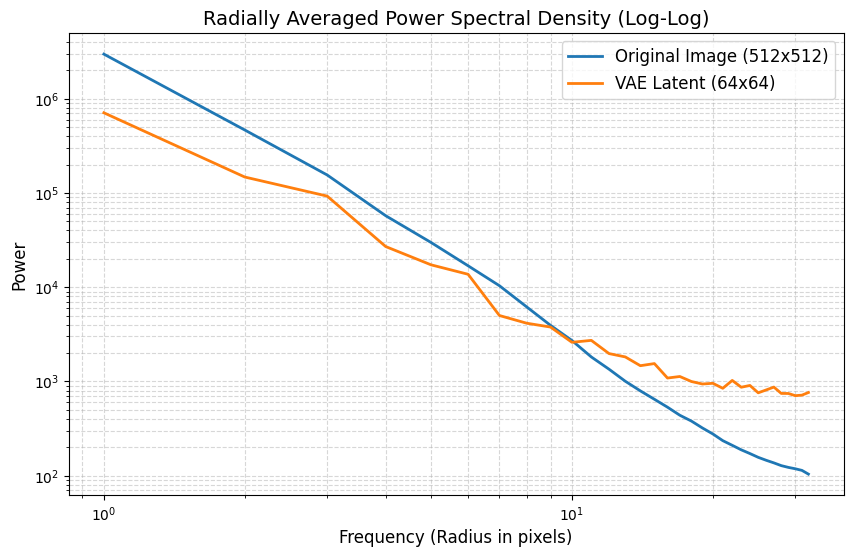

In [8]:
device = "mps"
print(f"Using device: {device}")

# A. Load the pretrained Stable Diffusion VAE
print("Loading VAE...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae = torch.compile(vae)
vae.eval() # Set to evaluation mode

# B. Load a sample image (or use a local path: Image.open("my_image.jpg"))
image_path = "./images/000010.jpg"
img = Image.open(image_path).convert("RGB")

# C. Preprocess the image for the VAE
# VAEs typically expect tensors in the range [-1, 1]
transform = transforms.Compose([
    transforms.Resize((512, 512)), # SD VAEs like multiples of 8 (usually 512x512)
    transforms.ToTensor(),         # Converts to [0, 1]
    transforms.Normalize([0.5], [0.5]) # Shifts to [-1, 1]
])

img_tensor = transform(img).unsqueeze(0).to(device) # Shape: (1, 3, 512, 512)

# E. Encode the image through the VAE
print("Encoding Image...")
with torch.no_grad():
    # The VAE outputs a distribution. We take the mean (mode) for deterministic latents.
    posterior = vae.encode(img_tensor).latent_dist
    latents = posterior.mode() 
    
    # Note: SD latents are scaled by a constant (usually 0.18215) in the diffusion process,
    # but for purely checking the spectrum shape of the raw latent, we don't strictly need it.
    # latents shape: (1, 4, 64, 64) - note how H and W are 8x smaller!
    latents = latents * 0.18215

print(f"Image shape: {img_tensor.shape}")
print(f"Latent shape: {latents.shape}")

psd_image = radial_power_spectrum(img_tensor)
psd_latent = radial_power_spectrum(latents)

# 2. Downsample the target to match latent dimensions
# F.interpolate expects 3D tensors: (Batch, Channels, Length)
psd_image = psd_image.unsqueeze(1)

# must move from mps to cpu for the interpolation
# probably works well on cuda
original_device = psd_image.device
psd_target_cpu = psd_image.cpu()

# Use mode='area' (average pooling) to preserve total energy distribution
psd_target_aligned = F.interpolate(
    psd_target_cpu, 
    size=psd_latent.shape[-1], 
    mode='area'
)

# Remove the dummy channel dimension: back to (Batch, 32)
psd_target_aligned = psd_target_aligned.to(original_device).squeeze(1)    

# Plot them together!
plot_dict = {
    "Original Image (512x512)": psd_target_aligned,
    "VAE Latent (64x64)": psd_latent
}

plot_multiple_psd_1d(plot_dict)

#### The paper's hypothesis is that the VAE's latent space has a different PSD than the original image, especially for higher frequencies. 
#### Looking at the right side of the orange line (between X-axis values $10^1$ and $30$), the latent PSD line flattens out. It stops dropping and turns into a slightly jagged, horizontal line, which corresponds to power spectra of random noise.
#### This flattening means that the VAE isn't storing high frequencies (clean, structured details), it is storing unstructured, uncorrelated noise. 
#### The paper's "Encoding Spectrum Matching" (ESM) aims to fix this. By applying the ESM loss during training, that orange line would be forced to continue sloping downward smoothly, preserving the structural hierarchy of the data rather than devolving into static at the edges.

### Spectrum Matching Loss

In [9]:
import torch.nn.functional as F

def esm_loss(latent_psd, target_psd, delta=0.3):
    # 1. Flatten the Image Target Spectrum
    psd_target = psd_image ** delta
    
    # 2. Downsample the target to match latent dimensions
    # F.interpolate expects 3D tensors: (Batch, Channels, Length)
    psd_target = psd_target.unsqueeze(1)
    
    # must move from mps to cpu for the interpolation
    # probably works well without on cuda
    original_device = psd_target.device
    psd_target_cpu = psd_target.cpu()
    
    # Use mode='area' (average pooling) to preserve total energy distribution
    psd_target_aligned = F.interpolate(
        psd_target_cpu, 
        size=psd_latent.shape[-1], 
        mode='area'
    )
    
    # Remove the dummy channel dimension: back to (Batch, 32)
    psd_target_aligned = psd_target_aligned.to(original_device).squeeze(1)    
    
    # 3. Normalize both into valid Probability Distributions (sum to 1)
    # Add a tiny epsilon to prevent division by zero
    P = psd_target_aligned / (psd_target_aligned.sum(dim=-1, keepdim=True) + 1e-8)
    Q = psd_latent / (psd_latent.sum(dim=-1, keepdim=True) + 1e-8)
    
    # 4. Calculate KL Divergence
    # Note: PyTorch's F.kl_div expects the INPUT (Q) to be in log-space, 
    # and the TARGET (P) to be in linear-space.
    log_Q = torch.log(Q + 1e-8)
    
    # reduction='batchmean' is the mathematically correct way to average KL div across a batch
    esm_loss = F.kl_div(log_Q, P, reduction='batchmean')
    
    return esm_loss
    

In [10]:
image_path = "./images/000010.jpg"

device = "mps"
print(f"Using device: {device}")

# A. Load the pretrained Stable Diffusion VAE
print("Loading VAE...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval() # Set to evaluation mode

# B. Load a sample image (or use a local path: Image.open("my_image.jpg"))
img = Image.open(image_path).convert("RGB")

# C. Preprocess the image for the VAE
# VAEs typically expect tensors in the range [-1, 1]
transform = transforms.Compose([
    transforms.Resize((512, 512)), # SD VAEs like multiples of 8 (usually 512x512)
    transforms.ToTensor(),         # Converts to [0, 1]
    transforms.Normalize([0.5], [0.5]) # Shifts to [-1, 1]
])

img_tensor = transform(img).unsqueeze(0).to(device) # Shape: (1, 3, 512, 512)

# E. Encode the image through the VAE
print("Encoding Image...")
with torch.no_grad():
    # The VAE outputs a distribution. We take the mean (mode) for deterministic latents.
    posterior = vae.encode(img_tensor).latent_dist
    latents = posterior.mode() 
    
    # Note: SD latents are scaled by a constant (usually 0.18215) in the diffusion process,
    # but for purely checking the spectrum shape of the raw latent, we don't strictly need it.
    # latents shape: (1, 4, 64, 64) - note how H and W are 8x smaller!
    # latents = latents * 0.18215

print(f"Image shape: {img_tensor.shape}")
print(f"Latent shape: {latents.shape}")

psd_image = radial_power_spectrum(img_tensor)
psd_latent = radial_power_spectrum(latents)


loss = esm_loss(psd_latent, psd_image)
loss

Using device: mps
Loading VAE...
Encoding Image...
Image shape: torch.Size([1, 3, 512, 512])
Latent shape: torch.Size([1, 4, 64, 64])


tensor(0.9534, device='mps:0')

In [11]:
# TODO: train routine for regular VAE and ESM-VAE

### Decoding Spectrum Matching

In [12]:
import random

def apply_low_pass_filter(tensor, radius):
    """
    Applies a frequency low-pass filter to a 4D spatial tensor.
    tensor shape: (B, C, H, W)
    """
    _, _, H, W = tensor.shape
    
    # 1. 2D Fourier Transform (F)
    fft_tensor = torch.fft.fft2(tensor, dim=(-2, -1))
    
    # Shift low frequencies to the center of the 2D grid
    fft_shifted = torch.fft.fftshift(fft_tensor, dim=(-2, -1))
    
    # 2. Create the circular Mask
    yc, xc = H // 2, W // 2
    y, x = torch.meshgrid(torch.arange(H) - yc, torch.arange(W) - xc, indexing='ij')
    
    # Calculate distance from center for every coordinate
    dist = torch.sqrt(x**2 + y**2).to(tensor.device)
    
    # Mask is 1 where distance is <= radius, 0 otherwise
    mask = (dist <= radius).float()
    
    # 3. Apply mask (deletes high frequencies outside the circle)
    # The mask shape (H, W) broadcasts automatically to (B, C, H, W)
    filtered_shifted = fft_shifted * mask
    
    # 4. Inverse Fourier Transform (F^-1)
    # Shift the center back to the corners
    filtered_fft = torch.fft.ifftshift(filtered_shifted, dim=(-2, -1))
    
    # Inverse transform. We call .real to discard floating point complex artifacts
    filtered_tensor = torch.fft.ifft2(filtered_fft, dim=(-2, -1)).real
    
    return filtered_tensor


def dsm_loss(decoder, image, latent):
    """
    Calculates the Decoding Spectrum Matching (DSM) Loss.
    image shape: (B, 3, 512, 512)
    latent shape: (B, 4, 64, 64)
    """
    
    # 1. Define dimensions and sample a random radius
    latent_H = latent.shape[-2]
    image_H = image.shape[-2]
    
    scale_factor = image_H // latent_H # e.g., 512 // 64 = 8
    
    R_max_latent = latent_H // 2 # 32
    
    # Sample r randomly from Uniform(0, R_max)
    r_latent = random.uniform(0, R_max_latent)
    r_image = r_latent * scale_factor
    
    # 2. Apply the filters (\mathcal{F}^{-1}(M_r \odot \mathcal{F}(x)))
    # Note: We use .clone() to ensure we don't mess up autograd graphs 
    # if these tensors are used elsewhere in your combined loss.
    filtered_image = apply_low_pass_filter(image.clone(), r_image)
    filtered_latent = apply_low_pass_filter(latent.clone(), r_latent)
    
    # 3. Decode the filtered latent
    # (Assuming your VAE decoder outputs the image directly)
    decoded_filtered_image = decoder(filtered_latent)
    
    # 4. Calculate Mean Squared Error
    dsm_loss = F.mse_loss(decoded_filtered_image, filtered_image)
    
    return dsm_loss

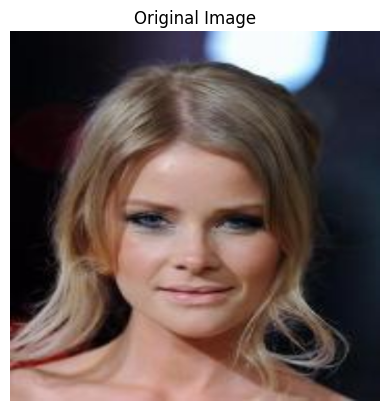

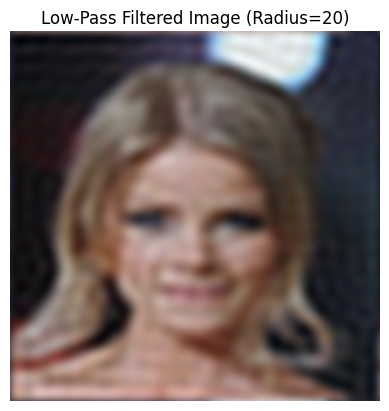

In [14]:
image_path = "./images/000010.jpg"
img = Image.open(image_path).convert("RGB")
img_tensor = transform(img).unsqueeze(0)

# radius = img_tensor.shape[-2] // 2
radius = 20

filtered_img = apply_low_pass_filter(img_tensor, radius=radius)

# Visualize the original and filtered images
def show_image(tensor, title="Image"):
    img_np = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min()) # Normalize to [0, 1]
    plt.imshow(img_np)
    plt.title(title)
    plt.axis("off")
    plt.show()
    plt.close()
    
show_image(img_tensor, title="Original Image")
show_image(filtered_img, title=f"Low-Pass Filtered Image (Radius={radius})")

In [15]:
# train regular VAE and spectrum-matching VAE, compare train progression
# - plot PSD difference
# - plot loss

# after train
# - plot reconstructions
# - 

In [16]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from diffusers import AutoencoderKL
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.image.fid import FrechetInceptionDistance
from torch.optim import AdamW
from tqdm import tqdm
import random

class SpectrumMatchingLosses(nn.Module):
    """
    Unified module for Encoding and Decoding Spectrum Matching Losses.
    Uses internal caching for meshgrids to maximize training speed.
    """
    def __init__(self, delta=0.3):
        super().__init__()
        self.delta = delta
        self.grid_cache = {} # Caches spatial grids to prevent recalculation

    # ==========================================
    # Helper: Grid Caching
    # ==========================================
    def _get_grids(self, H, W, device):
        """Generates and caches radial distance maps and binning variables."""
        key = (H, W, device)
        if key not in self.grid_cache:
            yc, xc = H // 2, W // 2
            y, x = torch.meshgrid(
                torch.arange(H, device=device) - yc, 
                torch.arange(W, device=device) - xc, 
                indexing='ij'
            )
            dist = torch.sqrt(x**2 + y**2)
            
            # Variables for radial_power_spectrum binning
            r_int = dist.round().long()
            max_r = int(min(H, W) / 2)
            valid_mask_flat = (r_int <= max_r).flatten()
            r_valid = r_int.flatten()[valid_mask_flat]
            
            counts = torch.zeros(max_r + 1, device=device)
            counts.scatter_add_(0, r_valid, torch.ones_like(r_valid, dtype=torch.float32))
            counts = counts + 1e-8 # Add epsilon once to avoid zero-division
            
            self.grid_cache[key] = {
                'dist': dist,
                'max_r': max_r,
                'valid_mask_flat': valid_mask_flat,
                'r_valid': r_valid,
                'counts': counts
            }
            
        return self.grid_cache[key]

    # ==========================================
    # Core Logic
    # ==========================================
    def radial_power_spectrum(self, tensor):
        """Calculates 1D Radial PSD."""
        if tensor.dim() == 3:
            tensor = tensor.unsqueeze(0)
            
        B, C, H, W = tensor.shape
        grids = self._get_grids(H, W, tensor.device)
        
        # 1. FFT and Shift
        f_coeffs = torch.fft.fft2(tensor, dim=(-2, -1))
        f_shifted = torch.fft.fftshift(f_coeffs, dim=(-2, -1))
        
        # 2. Power
        power_2d = torch.abs(f_shifted)**2
        power_2d = power_2d.mean(dim=1) # Average over channels: (B, H, W)
        
        # 3. Binning (Optimized)
        psd_1d = torch.zeros(B, grids['max_r'] + 1, device=tensor.device)
        
        power_flat = power_2d.view(B, -1)
        power_valid = power_flat[:, grids['valid_mask_flat']]
        
        r_expanded = grids['r_valid'].unsqueeze(0).expand(B, -1)
        psd_1d.scatter_add_(1, r_expanded, power_valid)
        
        # 4. Normalize
        psd_1d = psd_1d / grids['counts'].unsqueeze(0)
        return psd_1d

    def apply_low_pass_filter(self, tensor, radius):
        """Applies frequency low-pass filter using a circular mask."""
        B, C, H, W = tensor.shape
        grids = self._get_grids(H, W, tensor.device)
        
        fft_tensor = torch.fft.fft2(tensor, dim=(-2, -1))
        fft_shifted = torch.fft.fftshift(fft_tensor, dim=(-2, -1))
        
        mask = (grids['dist'] <= radius).float()
        filtered_shifted = fft_shifted * mask
        
        filtered_fft = torch.fft.ifftshift(filtered_shifted, dim=(-2, -1))
        filtered_tensor = torch.fft.ifft2(filtered_fft, dim=(-2, -1)).real
        
        return filtered_tensor

    # ==========================================
    # Loss Functions
    # ==========================================
    def esm_loss(self, psd_latent, psd_image):
        """Encoding Spectrum Matching Loss."""
        psd_target = psd_image ** self.delta
        B, L_latent = psd_latent.shape
        
        psd_target = psd_target.unsqueeze(1)
        
        # Target processing safely wrapped in no_grad. 
        # The target (image) does not require backprop, so moving to CPU is autograd-safe.
        with torch.no_grad():
            # if psd_target.device.type == 'mps':
            #     psd_target = F.interpolate(psd_target.cpu(), size=L_latent, mode='area').to(psd_latent.device)
            # else:
            #     psd_target = F.interpolate(psd_target, size=L_latent, mode='area')
            psd_target = F.interpolate(psd_target, size=L_latent, mode='bilater')

                
        psd_target_aligned = psd_target.squeeze(1)
        
        # Normalize to probability distributions
        P = psd_target_aligned / (psd_target_aligned.sum(dim=-1, keepdim=True) + 1e-8)
        Q = psd_latent / (psd_latent.sum(dim=-1, keepdim=True) + 1e-8)
        
        log_Q = torch.log(Q + 1e-8)
        return F.kl_div(log_Q, P, reduction='batchmean')

    def dsm_loss(self, decoder_fn, image, latent):
        """Decoding Spectrum Matching Loss."""
        latent_H = latent.shape[-2]
        image_H = image.shape[-2]
        scale_factor = image_H // latent_H 
        
        R_max_latent = latent_H // 2
        r_latent = random.uniform(0, R_max_latent)
        r_image = r_latent * scale_factor
        
        # FFT does not mutate in-place, so .clone() is safely removed to save VRAM
        filtered_image = self.apply_low_pass_filter(image, r_image)
        filtered_latent = self.apply_low_pass_filter(latent, r_latent)
        
        decoded = decoder_fn(filtered_latent)
        
        # Safely handle Diffusers AutoencoderKL output format
        if hasattr(decoded, 'sample'):
            decoded = decoded.sample
            
        # We detach the filtered_image to ensure MSE targets don't hold graphs
        return F.mse_loss(decoded, filtered_image.detach())

# ==========================================
# 1. Hardware & Optimization Setup
# ==========================================
# Auto-select best device. Enable CUDNN benchmarking for faster convolutions.
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

def to_uint8(tensor):
    """Converts [-1, 1] float tensors to [0, 255] uint8 for TorchMetrics."""
    return ((tensor.clamp(-1.0, 1.0) + 1.0) * 127.5).to(torch.uint8)

# ==========================================
# 2. iFID RAM-Efficient Latent Caching
# ==========================================
class LatentBank:
    """Caches recent latents to compute iFID without loading the whole dataset into RAM."""
    def __init__(self, max_size=1024):
        self.bank = None
        self.max_size = max_size

    def update(self, z):
        # Store detached latents on CPU to save GPU VRAM
        z_detached = z.detach().cpu()
        if self.bank is None:
            self.bank = z_detached
        else:
            self.bank = torch.cat([self.bank, z_detached], dim=0)[-self.max_size:]

    def get_interpolated_latents(self, z_batch):
        """Finds nearest neighbors in the bank and interpolates (alpha=0.5)."""
        if self.bank is None or len(self.bank) < z_batch.shape[0]:
            return z_batch # Fallback if bank isn't full yet
        
        # Flatten for Euclidean distance calculation
        B = z_batch.shape[0]
        z_flat = z_batch.view(B, -1)
        bank_flat = self.bank.view(self.bank.shape[0], -1).to(z_batch.device)
        
        # cdist computes pairwise distances efficiently
        dist = torch.cdist(z_flat, bank_flat)
        nn_idx = torch.argmin(dist, dim=1)
        
        z_nn = self.bank[nn_idx.cpu()].to(z_batch.device)
        
        # Interpolate halfway between the latent and its nearest neighbor
        return 0.5 * z_batch + 0.5 * z_nn

# ==========================================
# 3. Loss Functions
# ==========================================
def kl_loss(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / mu.shape[0]

# (Assuming radial_power_spectrum, esm_loss, apply_low_pass_filter, dsm_loss 
# are defined exactly as you wrote them in the context block).

# ==========================================
# 4. Main Training Loop
# ==========================================
def train_vae(use_spectrum_matching=False, epochs=5, batch_size=8, eval_every_n_steps=1):
    print(f"--- Starting Training ---")
    print(f"Device: {device} | Spectrum Matching: {use_spectrum_matching}")
    
    # Model Setup: Load untrained blueprint
    config = AutoencoderKL.load_config("stabilityai/sd-vae-ft-mse")
    vae = AutoencoderKL.from_config(config).to(device)
    vae = torch.compile(vae)
    optimizer = AdamW(vae.parameters(), lr=1e-4)
    
    spectrum_losses = SpectrumMatchingLosses(delta=0.3).to(device)

    # Telemetry Setup
    psnr_metric = PeakSignalNoiseRatio(data_range=2.0).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=2.0).to(device)
    
    # feature=64 uses an earlier Inception layer. It's much faster/lighter for 
    # quick training-loop telemetry than the default 2048.
    rfid_metric = FrechetInceptionDistance(feature=64).to("cpu")
    ifid_metric = FrechetInceptionDistance(feature=64).to("cpu")
    latent_bank = LatentBank(max_size=1024)

    # Data Setup (CelebA)
    transform = transforms.Compose([
        transforms.Resize((256, 256)), # Use 256 for faster testing, scale to 512 later
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    # dataset = datasets.CelebA(root='./data', split='train', download=True, transform=transform)
    # pin_memory=True speeds up CPU to GPU transfers
    dataset = datasets.ImageFolder(root='./data/archive/', transform=transform)
    
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)

    # Cache a fixed validation batch for consistent telemetry
    val_images = next(iter(dataloader))[0].to(device)
    val_images_uint8 = to_uint8(val_images)

    step = 0
    
    for epoch in range(epochs):
        vae.train()
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for images, _ in loop:
            images = images.to(device)
            optimizer.zero_grad(set_to_none=True)

            # Optional: Use Automatic Mixed Precision (AMP) if on CUDA for speed
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type=='cuda')):
                posterior = vae.encode(images).latent_dist
                z = posterior.sample()
                reconstructed = vae.decode(z).sample

                # 1. Base Losses
                recon_loss = F.mse_loss(reconstructed, images)
                reg_loss = kl_loss(posterior.mean, posterior.logvar)
                
                loss_total = recon_loss + (1e-6 * reg_loss)

                # 2. Unified Spectrum Losses
                if use_spectrum_matching:
                    psd_image = spectrum_losses.radial_power_spectrum(images)
                    psd_latent = spectrum_losses.radial_power_spectrum(z)
                    
                    loss_esm = spectrum_losses.esm_loss(psd_latent, psd_image)
                    loss_dsm = spectrum_losses.dsm_loss(vae.decode, images, z)
                    
                    loss_total += (0.1 * loss_esm) + (0.1 * loss_dsm)

            # Backprop
            # Use scaler if using AMP, otherwise standard backprop
            loss_total.backward()
            optimizer.step()

            # Update Latent Bank for iFID
            latent_bank.update(z)
            step += 1

            # ==========================================
            # Telemetry & Evaluation
            # ==========================================
            if step % eval_every_n_steps == 0:
                vae.eval()
                with torch.no_grad():
                    # Calculate PSNR & SSIM on current training batch
                    psnr_val = psnr_metric(reconstructed, images)
                    ssim_val = ssim_metric(reconstructed, images)

                    # ----- Calculate rFID and iFID on Validation Batch -----
                    val_post = vae.encode(val_images).latent_dist
                    val_z = val_post.sample()
                    
                    # 1. Standard Reconstruction (for rFID)
                    val_recon = vae.decode(val_z).sample
                    
                    # 2. Nearest Neighbor Interpolation (for iFID)
                    val_z_interp = latent_bank.get_interpolated_latents(val_z)
                    val_recon_interp = vae.decode(val_z_interp).sample

                    # Format for TorchMetrics (needs uint8 images)
                    val_recon_uint8 = to_uint8(val_recon)
                    val_recon_interp_uint8 = to_uint8(val_recon_interp)

                    # Update FID states
                    rfid_metric.update(val_images_uint8.cpu(), real=True)
                    rfid_metric.update(val_recon_uint8.cpu(), real=False)
                    
                    ifid_metric.update(val_images_uint8.cpu(), real=True)
                    ifid_metric.update(val_recon_interp_uint8.cpu(), real=False)

                    # Compute scores
                    # Compute scores
                    rfid_score = rfid_metric.compute()
                    ifid_score = ifid_metric.compute()

                    # Reset states for the next interval
                    rfid_metric.reset()
                    ifid_metric.reset()

                vae.train()

                # Update progress bar
                loop.set_postfix(
                    Loss=f"{loss_total.item():.4f}", 
                    MSE=f"{recon_loss.item():.4f}",
                    PSNR=f"{psnr_val.item():.2f}", 
                    rFID=f"{rfid_score.item():.2f}",
                    iFID=f"{ifid_score.item():.2f}"
                )


In [ ]:
# Execution examples:
train_vae(use_spectrum_matching=False, batch_size=8, eval_every_n_steps=100) # Trains baseline
train_vae(use_spectrum_matching=True)  # Trains your experimental method

--- Starting Training ---
Device: mps | Spectrum Matching: False


/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/Users/pahautelman/uni/master/DSAIT4030 Generative Modelling/spectrum-matching-project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/5:  38%|███▊      | 9514/25325 [9:38:53<15:57:47,  3.63s/it, Loss=0.0065, MSE=0.0033, PSNR=30.90, iFID=7.30, rFID=4.03]

In [ ]:
# TODO: check code, train-val-test splits, check iFID implementation
# TODO: optimize speed, choose a smaller vae
# TODO: save checkpoints, evals, weights